# Cognifyz Machine Learning Internship

## Task 2 — Restaurant Recommendation System

### Objective

Create a restaurant recommendation system based on user preferences.

### Approach

A content-based filtering approach will be used to recommend
restaurants that are similar to the user's preferred criteria.

### Recommendation Criteria

- Cuisine preference
- Price range
- City
- Restaurant rating
- Online delivery
- Table booking

In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [62]:
df = pd.read_csv(
    "../outputs/results/cleaned_restaurant_dataset.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (9551, 22)


In [63]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Primary Cuisine
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,French
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Japanese
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Seafood
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Japanese
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Japanese


In [64]:
recommendation_columns = [
    "Restaurant Name",
    "City",
    "Locality",
    "Cuisines",
    "Price range",
    "Aggregate rating",
    "Has Online delivery",
    "Has Table booking"
]

df[recommendation_columns].head()

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking
0,Le Petit Souffle,Makati City,"Century City Mall, Poblacion, Makati City","French, Japanese, Desserts",3,4.8,No,Yes
1,Izakaya Kikufuji,Makati City,"Little Tokyo, Legaspi Village, Makati City",Japanese,3,4.5,No,Yes
2,Heat - Edsa Shangri-La,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City","Seafood, Asian, Filipino, Indian",4,4.4,No,Yes
3,Ooma,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City","Japanese, Sushi",4,4.9,No,No
4,Sambo Kojin,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City","Japanese, Korean",4,4.8,No,Yes


In [65]:
df[recommendation_columns].isnull().sum()

Restaurant Name        0
City                   0
Locality               0
Cuisines               0
Price range            0
Aggregate rating       0
Has Online delivery    0
Has Table booking      0
dtype: int64

In [66]:
rec_df = df[recommendation_columns].copy()

In [67]:
rec_df.head()

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking
0,Le Petit Souffle,Makati City,"Century City Mall, Poblacion, Makati City","French, Japanese, Desserts",3,4.8,No,Yes
1,Izakaya Kikufuji,Makati City,"Little Tokyo, Legaspi Village, Makati City",Japanese,3,4.5,No,Yes
2,Heat - Edsa Shangri-La,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City","Seafood, Asian, Filipino, Indian",4,4.4,No,Yes
3,Ooma,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City","Japanese, Sushi",4,4.9,No,No
4,Sambo Kojin,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City","Japanese, Korean",4,4.8,No,Yes


In [68]:
text_columns = [
    "City",
    "Locality",
    "Cuisines"
]

for col in text_columns:
    rec_df[col] = (
        rec_df[col]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

In [69]:
rec_df[
    ["City", "Locality", "Cuisines"]
].head()

,City,Locality,Cuisines
0,makati city,"century city mall, poblacion, makati city","french, japanese, desserts"
1,makati city,"little tokyo, legaspi village, makati city",japanese
2,mandaluyong city,"edsa shangri-la, ortigas, mandaluyong city","seafood, asian, filipino, indian"
3,mandaluyong city,"sm megamall, ortigas, mandaluyong city","japanese, sushi"
4,mandaluyong city,"sm megamall, ortigas, mandaluyong city","japanese, korean"


In [70]:
rec_df["Price range"].value_counts().sort_index()

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

In [71]:
rec_df["Aggregate rating"].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

In [72]:
rec_df["content"] = (
    rec_df["Cuisines"] + " " +
    rec_df["Locality"] + " " +
    rec_df["City"]
)

In [73]:
rec_df[
    [
        "Restaurant Name",
        "City",
        "Locality",
        "Cuisines",
        "content"
    ]
].head()

,Restaurant Name,City,Locality,Cuisines,content
0,Le Petit Souffle,makati city,"century city mall, poblacion, makati city","french, japanese, desserts","french, japanese, desserts century city mall, ..."
1,Izakaya Kikufuji,makati city,"little tokyo, legaspi village, makati city",japanese,"japanese little tokyo, legaspi village, makati..."
2,Heat - Edsa Shangri-La,mandaluyong city,"edsa shangri-la, ortigas, mandaluyong city","seafood, asian, filipino, indian","seafood, asian, filipino, indian edsa shangri-..."
3,Ooma,mandaluyong city,"sm megamall, ortigas, mandaluyong city","japanese, sushi","japanese, sushi sm megamall, ortigas, mandaluy..."
4,Sambo Kojin,mandaluyong city,"sm megamall, ortigas, mandaluyong city","japanese, korean","japanese, korean sm megamall, ortigas, mandalu..."


In [74]:
tfidf = TfidfVectorizer(
    stop_words="english"
)

In [75]:
tfidf_matrix = tfidf.fit_transform(
    rec_df["content"]
)

In [76]:
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9551, 1561)


In [77]:
cosine_sim = cosine_similarity(tfidf_matrix)

In [78]:
print("Similarity matrix shape:", cosine_sim.shape)

Similarity matrix shape: (9551, 9551)


In [79]:
cosine_similarity(tfidf_matrix)

array([[1.        , 0.62525117, 0.15797053, ..., 0.        , 0.        ,
        0.        ],
       [0.62525117, 1.        , 0.1090209 , ..., 0.        , 0.        ,
        0.        ],
       [0.15797053, 0.1090209 , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.6816648 ,
        0.23577763],
       [0.        , 0.        , 0.        , ..., 0.6816648 , 1.        ,
        0.31657817],
       [0.        , 0.        , 0.        , ..., 0.23577763, 0.31657817,
        1.        ]], shape=(9551, 9551))

In [80]:
indices = pd.Series(
    rec_df.index,
    index=rec_df["Restaurant Name"].str.lower()
).drop_duplicates()

In [81]:
indices.head()

Restaurant Name
le petit souffle          0
izakaya kikufuji          1
heat - edsa shangri-la    2
ooma                      3
sambo kojin               4
dtype: int64

In [82]:
def recommend_similar_restaurants(
    restaurant_name,
    top_n=10
):
    restaurant_name = restaurant_name.lower()

    if restaurant_name not in indices:
        return pd.DataFrame()

    idx = indices[restaurant_name]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n + 1]

    restaurant_indices = [
        i[0] for i in similarity_scores
    ]

    result = rec_df.iloc[
        restaurant_indices
    ].copy()

    result["Similarity Score"] = [
        i[1] for i in similarity_scores
    ]

    return result

In [83]:
rec_df[
    "Restaurant Name"
].head(10)

0                            Le Petit Souffle
1                            Izakaya Kikufuji
2                      Heat - Edsa Shangri-La
3                                        Ooma
4                                 Sambo Kojin
5                                Din Tai Fung
6                                  Buffet 101
7                                     Vikings
8    Spiral - Sofitel Philippine Plaza Manila
9                                    Locavore
Name: Restaurant Name, dtype: str

In [84]:
recommend_similar_restaurants(
    "Restaurant X",
    top_n=5
)

""


In [85]:
user_preferences = {
    "city": "New Delhi",
    "cuisine": "North Indian",
    "price_range": 2,
    "min_rating": 4.0,
    "online_delivery": "Yes"
}

user_preferences

{'city': 'New Delhi',
 'cuisine': 'North Indian',
 'price_range': 2,
 'min_rating': 4.0,
 'online_delivery': 'Yes'}

In [86]:
filtered_df = rec_df.copy()

In [87]:
filtered_df = filtered_df[
    filtered_df["City"] == user_preferences["city"].lower()
]

In [88]:
filtered_df = filtered_df[
    filtered_df["Price range"] ==
    user_preferences["price_range"]
]

In [89]:
filtered_df = filtered_df[
    filtered_df["Aggregate rating"] >=
    user_preferences["min_rating"]
]

In [90]:
filtered_df = filtered_df[
    filtered_df["Has Online delivery"] ==
    user_preferences["online_delivery"]
]

In [91]:
print("Restaurants matching filters:", len(filtered_df))

Restaurants matching filters: 59


In [92]:
user_content = (
    user_preferences["cuisine"].lower() + " " +
    user_preferences["city"].lower()
)

In [93]:
user_vector = tfidf.transform(
    [user_content]
)

In [94]:
rec_df["Restaurant Name"].head(10)

0                            Le Petit Souffle
1                            Izakaya Kikufuji
2                      Heat - Edsa Shangri-La
3                                        Ooma
4                                 Sambo Kojin
5                                Din Tai Fung
6                                  Buffet 101
7                                     Vikings
8    Spiral - Sofitel Philippine Plaza Manila
9                                    Locavore
Name: Restaurant Name, dtype: str

In [95]:
recommend_similar_restaurants(
    "fLe Petit Soufle",
    top_n=5
)

""


In [96]:
recommendations = recommend_similar_restaurants(
    "fLe Petit Soufle",
    top_n=5
)

recommendations

""


# Day 7 — Task 2 Progress

## Work Completed

- Loaded the cleaned restaurant dataset.
- Selected features relevant to restaurant recommendations.
- Cleaned categorical/text features.
- Created a combined content representation using cuisine,
  locality, and city.
- Applied TF-IDF vectorization to represent restaurant content.
- Calculated cosine similarity between restaurant profiles.
- Created a basic similarity-based recommendation function.
- Defined sample user preferences for the final recommendation system.

## Recommendation Approach

The planned recommendation system uses a content-based filtering
approach. User preferences will first be used to filter suitable
restaurants, followed by similarity-based ranking.

## Next Step

The recommendation logic will be converted into a reusable function
that accepts user preferences and returns the top recommended
restaurants.

In [97]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [98]:
print("Restaurants:", len(rec_df))
print("TF-IDF matrix shape:", tfidf_matrix.shape)

Restaurants: 9551
TF-IDF matrix shape: (9551, 1561)


In [99]:
cosine_sim = cosine_similarity(tfidf_matrix)

In [100]:
user_similarity = cosine_similarity(
    user_vector,
    tfidf_matrix
).flatten()

# Final Recommendation System

In [101]:
def recommend_restaurants(
    city,
    cuisine,
    price_range,
    min_rating=0.0,
    online_delivery=None,
    top_n=10
):
    """
    Recommend restaurants based on user preferences.

    Parameters:
        city: preferred city
        cuisine: preferred cuisine
        price_range: preferred price range (1-4)
        min_rating: minimum acceptable restaurant rating
        online_delivery: "Yes", "No", or None
        top_n: number of recommendations

    Returns:
        DataFrame containing recommended restaurants.
    """

    # Work on a copy
    filtered_df = rec_df.copy()

    # Normalize user inputs
    city = str(city).strip().lower()
    cuisine = str(cuisine).strip().lower()

    # -----------------------------
    # 1. Filter by city
    # -----------------------------
    filtered_df = filtered_df[
        filtered_df["City"] == city
    ]

    # -----------------------------
    # 2. Filter by cuisine
    # -----------------------------
    filtered_df = filtered_df[
        filtered_df["Cuisines"].str.contains(
            cuisine,
            case=False,
            na=False,
            regex=False
        )
    ]

    # -----------------------------
    # 3. Filter by price range
    # -----------------------------
    filtered_df = filtered_df[
        filtered_df["Price range"] == price_range
    ]

    # -----------------------------
    # 4. Filter by minimum rating
    # -----------------------------
    filtered_df = filtered_df[
        filtered_df["Aggregate rating"] >= min_rating
    ]

    # -----------------------------
    # 5. Filter by online delivery
    # -----------------------------
    if online_delivery is not None:
        filtered_df = filtered_df[
            filtered_df["Has Online delivery"].str.lower()
            == str(online_delivery).strip().lower()
        ]

    # Check whether anything matched
    if filtered_df.empty:
        return pd.DataFrame(
            columns=[
                "Restaurant Name",
                "City",
                "Locality",
                "Cuisines",
                "Price range",
                "Aggregate rating",
                "Has Online delivery",
                "Has Table booking",
                "Similarity Score"
            ]
        )

    # -----------------------------
    # 6. Create user preference text
    # -----------------------------
    user_content = (
        cuisine + " " +
        city
    )

    # Convert user preference to TF-IDF
    user_vector = tfidf.transform(
        [user_content]
    )

    # -----------------------------
    # 7. Calculate similarity
    # -----------------------------
    similarities = cosine_similarity(
        user_vector,
        tfidf_matrix[filtered_df.index]
    ).flatten()

    # -----------------------------
    # 8. Add similarity score
    # -----------------------------
    filtered_df = filtered_df.copy()

    filtered_df["Similarity Score"] = similarities

    # -----------------------------
    # 9. Rank restaurants
    # -----------------------------
    filtered_df = filtered_df.sort_values(
        by=["Similarity Score", "Aggregate rating"],
        ascending=[False, False]
    )

    # -----------------------------
    # 10. Return Top N
    # -----------------------------
    return filtered_df.head(top_n)

In [102]:
recommendations = recommend_restaurants(
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery="Yes",
    top_n=10
)

recommendations

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,Yes,No,"north indian, south indian, chinese rajinder n...",0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,Yes,No,"south indian, north indian, chinese defence co...",0.453838
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,Yes,No,"north indian, mughlai malviya nagar new delhi",0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,Yes,Yes,"north indian, fast food malviya nagar new delhi",0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,Yes,No,"north indian, chinese, continental janakpuri n...",0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,Yes,Yes,"north indian, mughlai, chinese rajinder nagar ...",0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,Yes,No,"north indian, chinese defence colony new delhi",0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,Yes,No,"cafe, north indian, chinese, continental satya...",0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,Yes,Yes,"north indian, chinese, cafe delhi university-g...",0.389284
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,Yes,No,"north indian, chinese, continental rajouri gar...",0.377300


In [103]:
recommendations[
    [
        "Restaurant Name",
        "City",
        "Locality",
        "Cuisines",
        "Price range",
        "Aggregate rating",
        "Has Online delivery",
        "Similarity Score"
    ]
]

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,Yes,0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,Yes,0.453838
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,Yes,0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,Yes,0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,Yes,0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,Yes,0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,Yes,0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,Yes,0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,Yes,0.389284
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,Yes,0.377300


In [104]:
test_df = rec_df.copy()

test_df = test_df[
    test_df["City"] == "new delhi"
]

test_df = test_df[
    test_df["Cuisines"].str.contains(
        "north indian",
        case=False,
        na=False,
        regex=False
    )
]

test_df = test_df[
    test_df["Price range"] == 2
]

test_df = test_df[
    test_df["Aggregate rating"] >= 4.0
]

test_df = test_df[
    test_df["Has Online delivery"].str.lower() == "yes"
]

print("Restaurants matching preferences:", len(test_df))

Restaurants matching preferences: 26


In [105]:
recommendations_2 = recommend_restaurants(
    city="Gurgaon",
    cuisine="Chinese",
    price_range=2,
    min_rating=3.5,
    online_delivery="Yes",
    top_n=10
)

recommendations_2

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score
2030,Cafe Cup of Life,gurgaon,sector 7,"cafe, fast food, chinese",2,3.7,Yes,No,"cafe, fast food, chinese sector 7 gurgaon",0.562182
1388,Happy Beings,gurgaon,dlf phase 3,"north indian, mughlai, chinese",2,3.5,Yes,No,"north indian, mughlai, chinese dlf phase 3 gur...",0.472055
1324,Angrezee Choupal,gurgaon,dlf phase 2,"north indian, chinese, italian",2,3.8,Yes,No,"north indian, chinese, italian dlf phase 2 gur...",0.465902
1384,China Gatherings,gurgaon,dlf phase 3,"chinese, thai",2,3.5,Yes,No,"chinese, thai dlf phase 3 gurgaon",0.456334
1413,My Country Platter,gurgaon,dlf phase 4,"asian, chinese, north indian",2,3.8,Yes,No,"asian, chinese, north indian dlf phase 4 gurgaon",0.436167
1943,Nite Bites,gurgaon,sector 45,"north indian, chinese, continental",2,3.7,Yes,No,"north indian, chinese, continental sector 45 g...",0.422729
2082,Tandoori Nation,gurgaon,sohna road,"north indian, mughlai, chinese",2,3.5,Yes,No,"north indian, mughlai, chinese sohna road gurgaon",0.418392
1421,Happy Hakka,gurgaon,dlf phase 4,"chinese, asian, thai",2,4.1,Yes,No,"chinese, asian, thai dlf phase 4 gurgaon",0.398965
2128,Dilli Darbar,gurgaon,sushant lok,"north indian, mughlai, chinese",2,3.7,Yes,No,"north indian, mughlai, chinese sushant lok gur...",0.388369
1491,The Gathering Hut,gurgaon,golf course road,"north indian, chinese",2,3.5,Yes,No,"north indian, chinese golf course road gurgaon",0.380008


In [106]:
recommendations_3 = recommend_restaurants(
    city="New Delhi",
    cuisine="Italian",
    price_range=3,
    min_rating=4.0,
    online_delivery="No",
    top_n=5
)

recommendations_3

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score
6717,The Drunk House,new delhi,rajouri garden,"north indian, italian, chinese",3,4.2,No,No,"north indian, italian, chinese rajouri garden ...",0.460238
3120,{Niche} - Cafe & Bar,new delhi,connaught place,"north indian, chinese, italian, continental",3,4.1,No,Yes,"north indian, chinese, italian, continental co...",0.438872
3093,Ambrosia Bliss,new delhi,connaught place,"north indian, chinese, italian, continental",3,4.0,No,Yes,"north indian, chinese, italian, continental co...",0.438872
3976,Summer House Cafe,new delhi,hauz khas,"italian, continental",3,4.1,No,Yes,"italian, continental hauz khas new delhi",0.434351
6703,Calendar's Kitchen by Satish Kaushik,new delhi,rajouri garden,"continental, italian, north indian, chinese",3,4.0,No,Yes,"continental, italian, north indian, chinese ra...",0.428207


In [107]:
online_delivery=None

In [108]:
recommendations_4 = recommend_restaurants(
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery=None,
    top_n=10
)

recommendations_4

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,Yes,No,"north indian, south indian, chinese rajinder n...",0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,Yes,No,"south indian, north indian, chinese defence co...",0.453838
6848,Rajinder Da Dhaba,new delhi,safdarjung,"north indian, mughlai, chinese",2,4.3,No,No,"north indian, mughlai, chinese safdarjung new ...",0.438034
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,Yes,No,"north indian, mughlai malviya nagar new delhi",0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,Yes,Yes,"north indian, fast food malviya nagar new delhi",0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,Yes,No,"north indian, chinese, continental janakpuri n...",0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,Yes,Yes,"north indian, mughlai, chinese rajinder nagar ...",0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,Yes,No,"north indian, chinese defence colony new delhi",0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,Yes,No,"cafe, north indian, chinese, continental satya...",0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,Yes,Yes,"north indian, chinese, cafe delhi university-g...",0.389284


In [109]:
no_result_test = recommend_restaurants(
    city="New Delhi",
    cuisine="Japanese",
    price_range=4,
    min_rating=4.9,
    online_delivery="Yes",
    top_n=10
)

no_result_test

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,Similarity Score


In [110]:
if no_result_test.empty:
    print("No restaurants match the selected preferences.")

No restaurants match the selected preferences.


In [111]:
if no_result_test.empty:
    print(
        "No restaurants matched all the selected preferences. "
        "Try relaxing the minimum rating, price range, "
        "or delivery requirement."
    )

No restaurants matched all the selected preferences. Try relaxing the minimum rating, price range, or delivery requirement.


In [112]:
recommendations.to_csv(
    "../outputs/results/task2_sample_recommendations.csv",
    index=False
)

In [113]:
def validate_recommendations(
    recommendations,
    city,
    cuisine,
    price_range,
    min_rating,
    online_delivery=None
):
    if recommendations.empty:
        return {
            "recommendations_found": 0,
            "city_match": 0,
            "cuisine_match": 0,
            "price_match": 0,
            "rating_match": 0,
            "delivery_match": 0 if online_delivery else None
        }

    city_match = (
        recommendations["City"].str.lower() == city.lower()
    ).all()

    cuisine_match = (
        recommendations["Cuisines"]
        .str.contains(
            cuisine,
            case=False,
            na=False,
            regex=False
        )
    ).all()

    price_match = (
        recommendations["Price range"] == price_range
    ).all()

    rating_match = (
        recommendations["Aggregate rating"] >= min_rating
    ).all()

    if online_delivery is not None:
        delivery_match = (
            recommendations["Has Online delivery"]
            .str.lower()
            == online_delivery.lower()
        ).all()
    else:
        delivery_match = None

    return {
        "recommendations_found": len(recommendations),
        "city_match": city_match,
        "cuisine_match": cuisine_match,
        "price_match": price_match,
        "rating_match": rating_match,
        "delivery_match": delivery_match
    }

In [114]:
validation = validate_recommendations(
    recommendations,
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery="Yes"
)

validation

{'recommendations_found': 10,
 'city_match': np.True_,
 'cuisine_match': np.True_,
 'price_match': np.True_,
 'rating_match': np.True_,
 'delivery_match': np.True_}

In [115]:
if not recommendations.empty:
    avg_similarity = recommendations[
        "Similarity Score"
    ].mean()

    print(
        "Average recommendation similarity:",
        round(avg_similarity, 4)
    )

Average recommendation similarity: 0.4176


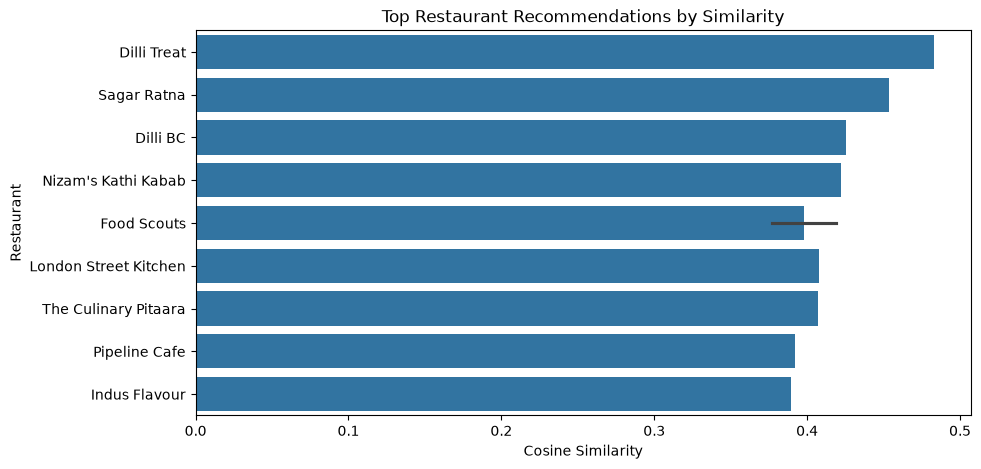

In [116]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=recommendations,
    x="Similarity Score",
    y="Restaurant Name"
)

plt.title(
    "Top Restaurant Recommendations by Similarity"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Restaurant")

plt.savefig(
    "../outputs/figures/task2_recommendation_similarity.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [117]:
recommendation_summary = recommendations[
    [
        "Restaurant Name",
        "City",
        "Locality",
        "Cuisines",
        "Price range",
        "Aggregate rating",
        "Similarity Score"
    ]
].copy()

recommendation_summary

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,0.453838
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,0.389284
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,0.377300


In [118]:
recommendation_summary.to_csv(
    "../outputs/results/task2_recommendation_summary.csv",
    index=False
)

In [119]:
recommend_restaurants(
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery="Yes",
    top_n=10
)

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,Yes,No,"north indian, south indian, chinese rajinder n...",0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,Yes,No,"south indian, north indian, chinese defence co...",0.453838
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,Yes,No,"north indian, mughlai malviya nagar new delhi",0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,Yes,Yes,"north indian, fast food malviya nagar new delhi",0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,Yes,No,"north indian, chinese, continental janakpuri n...",0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,Yes,Yes,"north indian, mughlai, chinese rajinder nagar ...",0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,Yes,No,"north indian, chinese defence colony new delhi",0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,Yes,No,"cafe, north indian, chinese, continental satya...",0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,Yes,Yes,"north indian, chinese, cafe delhi university-g...",0.389284
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,Yes,No,"north indian, chinese, continental rajouri gar...",0.377300


The recommendation system uses content-based similarity based
primarily on cuisine and location-related textual features.
Price range, minimum rating, and online delivery are applied as
user preference filters before similarity-based ranking.

# Task 2 — Conclusion

A content-based restaurant recommendation system was developed
using the restaurant dataset.

The system accepts user preferences including:

- City
- Cuisine
- Price range
- Minimum rating
- Online delivery preference

Restaurants are first filtered according to the selected hard
constraints. The remaining restaurant profiles are represented
using TF-IDF based on cuisine and location-related text features.
Cosine similarity is then used to rank restaurants according to
their similarity to the user's preferences.

The system was tested using multiple sample user preference
combinations and successfully returned ranked restaurant
recommendations.

### Limitation

The dataset does not contain actual user-item interaction or
feedback data. Therefore, conventional recommendation metrics
such as precision@k or recall@k cannot be reliably calculated
from the provided dataset alone. Recommendation quality was
instead validated using preference-matching checks and
similarity scores.